# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [5]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab


In [6]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [7]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/ratings_train.txt
이미 존재합니다: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab/data/nsmc_lm_val.txt


In [8]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [9]:
run_pytest("tests/test_bpe.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.01s ===============================


0

In [10]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [11]:
run_pytest("tests/test_dataset.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 0.76s ===============================


선택한 테스트를 통과했습니다.


0

In [12]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [13]:
run_pytest("tests/test_attention.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 0.36s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [14]:
run_pytest("tests/test_model.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape

0

In [15]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [16]:
run_pytest("tests/test_train.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_train.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

=============================== warnings summary ===============================
tests/test_train.py::TestPlotLosses::test_plot_los

0

In [17]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.721822261810303


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [18]:
run_pytest("tests/test_finetune.py")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 0.36s ===============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [19]:
run_pytest("tests/")

실행 명령: /Users/hmm/miniforge3/envs/mini-gpt/bin/python -m pytest tests/ -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/hmm/miniforge3/envs/mini-gpt/bin/python
cachedir: .pytest_cache
rootdir: /Users/hmm/Desktop/jungle/mini_gpt/week14-team02-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED       

0

In [20]:
import torch

from bpe import BPETokenizer
from dataset import create_dataloader
from model import GPTModel
from train import train_model, plot_losses, generate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [21]:
small_corpus = corpus[:100000]

print("chars:", len(small_corpus))
print(small_corpus[:100000])

chars: 100000
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고 생각합니다..
첫번째 에피소드 정말.... 엄청난소름
미국 경찰은 아무나 못해먹겠네 ㄷㄷ
발생시기는 2011년초, 최초발생장소는 센다이로 재앙의 내용만 다르지 정확한 예언
도가 지나치게 재미없다
헐리웃에서 사지절단하면 추앙받고 한국에서 사지절단하면 욕먹고.ㅋㅋ 잘돌아간다.
캐스팅만으로도 10점
모세의 기적 응원합니다~!
덴젤 워싱턴, 에단 호크.. 더이상 말이 필요없지!!
공포,고어물이 평점이원래낮아서..근데 이영화는 진짜 머하나볼께없다.지루함.
머야 이거 센과 치히로 보다 재밋네?
마지막을 위한 영화 걍 줄거리 파악 말구 일단 강추아닥 걍 봐 ㅋㅋㅋ
진~~~~~~~~~~짜 재.미.없.다!!!!!! 완전 지루하고 잠온다.4시간처럼 느껴졌음
어디 비교 할 게 없어서 명작 파고랑 비교해. 그저 아류 짝퉁이구만.
돈 아깝다 보지마시라 저질 미국 영화임
아 진심 이런 뭔내용인지이해하나도안감 아 기분만찜찜해
영화의 흐름을 방해하는 과도한 그래픽, 워쇼스키의 또다른 모험수,
언제쯤 세상을 위해 이들이 없어질까
폭력배한테 맞을때 진짜처럼 당하던데.
조으다ㅠㅠ 완전 좋습니다 ㅠㅠㅠ
아.. 책은 정말 재밌는데 어쩜.. 영화를 이렇게 허접하게 만들었는지.. 원작이 너무 아까움... 그나마 제이스와 클라리역을 맡은 연기자들 외모가 좋아서 다행..
은근잼잇는영화에요~헤어진연인들이보기좋겟네요ㅎ
이게 2014년 작품이란게 놀랄 따름이다. 20년 전에 나왔다고 해도 전혀 의심하지 않을 cg. 견자단이랑 주윤발은 왜 이런 영화에 나왔는지
님들 정말 이게 재밌어요? 내가 제임스 맥어보이 팬이라 꾹 참고 빠른재생으

In [63]:
# BASE_CONFIG = {
#     "vocab_size": 1000,
#     "context_length": 64,
#     "emb_dim": 128,
#     "n_heads": 4,
#     "n_layers": 2,
#     "drop_rate": 0.1,
#     "qkv_bias": False,
# }

# TRAIN_CONFIG = {
#     "batch_size": 4,
#     "learning_rate": 5e-4,
#     "num_epochs": 4,
#     "eval_freq": 20,
#     "eval_iter": 5,
# }

BASELINE_BASE_CONFIG = {
    "vocab_size": 1000,
    "context_length": 64,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

BASELINE_TRAIN_CONFIG = {
    "batch_size": 4,
    "learning_rate": 5e-4,
    "num_epochs": 5,
    "eval_freq": 100,
    "eval_iter": 5,
}

In [64]:
EXPERIMENTS = [
    {
        "name": "baseline_lr5e-4",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "lr_3e-4",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 3e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "dropout_0.0",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.0,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "dropout_0.2",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.2,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "batch_8",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 8,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "context_128",
        "base": {
            "vocab_size": 1000,
            "context_length": 128,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "layers_1",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 1,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "layers_4",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 4,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "emb_64",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 64,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
    {
        "name": "emb_192",
        "base": {
            "vocab_size": 1000,
            "context_length": 64,
            "emb_dim": 192,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        },
        "train": {
            "batch_size": 4,
            "learning_rate": 5e-4,
            "num_epochs": 5,
            "eval_freq": 100,
            "eval_iter": 5,
        },
    },
]

In [65]:
tokenizer = BPETokenizer(vocab_size=BASE_CONFIG["vocab_size"])
tokenizer.train(small_corpus)

token_ids = tokenizer.encode(small_corpus)

print("num token ids:", len(token_ids))
print(token_ids[:20])

sample_text = small_corpus[:300]
sample_ids = tokenizer.encode(sample_text)
print(tokenizer.decode(sample_ids))

num token ids: 82148
[661, 713, 400, 379, 881, 309, 779, 785, 591, 309, 503, 742, 537, 493, 321, 426, 359, 328, 239, 725]
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고 생각합니다..
첫번째 에피소드 정말.... 엄청난소름
미국 경찰은 아무나 못해먹겠네 ㄷㄷ
발생시기는 2011년초, 최초발생장소는 센다이로 재앙의 내용만 다르지 정확한 예언
도가 


In [55]:
split_idx = int(len(token_ids) * 0.9)

train_ids = token_ids[:split_idx]
val_ids = token_ids[split_idx:]

print("train ids:", len(train_ids))
print("val ids:", len(val_ids))

train ids: 73933
val ids: 8215


In [56]:
train_loader = create_dataloader(
    train_ids,
    context_length=BASE_CONFIG["context_length"],
    batch_size=TRAIN_CONFIG["batch_size"],
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=BASE_CONFIG["context_length"],
    batch_size=TRAIN_CONFIG["batch_size"],
    shuffle=False,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

inp, tgt = next(iter(train_loader))
print(inp.shape, tgt.shape)

train batches: 289
val batches: 32
torch.Size([4, 64]) torch.Size([4, 64])


In [66]:
import types
from bpe import SPECIAL_IDS

def safe_decode(self, ids, skip_special=True):
    byte_values = []

    for token_id in ids:
        token_id = int(token_id)

        if skip_special and token_id in SPECIAL_IDS.values():
            continue

        byte_values.extend(self.token_to_bytes(token_id))

    return bytes(byte_values).decode("utf-8", errors="replace")

tokenizer.decode = types.MethodType(safe_decode, tokenizer)

In [67]:
model = GPTModel(BASE_CONFIG).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAIN_CONFIG["learning_rate"],
)

num_params = sum(p.numel() for p in model.parameters())
print("num params:", num_params)

num params: 660224


In [59]:
train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=TRAIN_CONFIG["num_epochs"],
    eval_freq=TRAIN_CONFIG["eval_freq"],
    eval_iter=TRAIN_CONFIG["eval_iter"],
    start_context="영화",
    tokenizer=tokenizer,
)

Epoch 1, Step 20: Train loss 6.869, Val loss 6.882
영화 좋�제저하게지만....
 10점이 좀렇게� 보 아닄요티0 기억보히 어 �" 볼o어 �선 영노좩생�� �이�진군 이에 좀� 뭐고그 수
Epoch 1, Step 40: Train loss 6.462, Val loss 6.515
영화에하나�리어��이 이의도고이가이다어나�이가�
이 너무�라�리이���는지 가이�가는에 대고이��의�
Epoch 1, Step 60: Train loss 6.281, Val loss 6.387
영화이한지�는 영화�가
아�다 �는리� 지��이�에�이���을 영화 이는지아�의�는이�다��고���
�
Epoch 1, Step 80: Train loss 6.263, Val loss 6.355
영화한리의
 나하다 은다�은이가��은만�는�은이��이�지게��.
�게의이 지만...고가�이����
Epoch 1, Step 100: Train loss 6.246, Val loss 6.366
영화
�는는 �어��한한도이는도이�지
가나�
이�고는에는
하��에...�게.�이��하도 그
이� 이 
Epoch 1, Step 120: Train loss 6.268, Val loss 6.345
영화�의가는���이에�기
영화.
��는�는�고��
 �도다이�나�다�가� .의의어고봰이다�다
Epoch 1, Step 140: Train loss 6.270, Val loss 6.354
영화의게나�지가��고.... 한에���한�이에.고고 영화어기는가
 이�는
�이가어 영화에 이� 이는 다
..이
Epoch 1, Step 160: Train loss 6.289, Val loss 6.359
영화�� �의는이인가인� 나지이도�
 � �나지이�스�도�이이나 �
의�이..�� 이가은고�고는이이
Epoch 1, Step 180: Train loss 6.239, Val loss 6.347
영화도� 이에
�어라요�도�
�의���한요지�인이은��에�의�가고고��의가�
이�지���도어고

Epoch 1

final train loss: 4.699572467803955
final val loss: 5.364703178405762


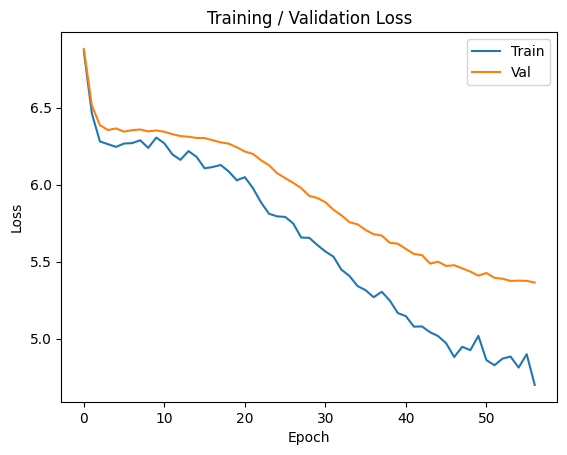

In [60]:
from train import calc_loss_loader

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=TRAIN_CONFIG["eval_iter"],
)

print("final train loss:", train_losses[-1])
print("final val loss:", val_losses[-1])
plot_losses(train_losses, val_losses)

In [61]:
model.eval()

prompt = "영화"
idx = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long,
    device=device,
).unsqueeze(0)

generated_ids = generate(
    model=model,
    idx=idx,
    max_new_tokens=50,
    context_size=BASE_CONFIG["context_length"],
    temperature=0.8,
    top_k=40,
)

print(tokenizer.decode(generated_ids[0].tolist()))

영화
�을때 쓰레기. 하는지않고 앁나서,은 계준은 미국거고 홬면시정을 잼도 못다 이쁘들도 재미있다면 리음 


In [62]:
for temp, top_k in [
    (0.0, None),
    (0.5, 10),
    (0.8, 40),
]:
    idx = torch.tensor(
        tokenizer.encode("영화"),
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    generated_ids = generate(
        model=model,
        idx=idx,
        max_new_tokens=50,
        context_size=BASE_CONFIG["context_length"],
        temperature=temp,
        top_k=top_k,
    )

    print("temperature:", temp, "top_k:", top_k)
    print(tokenizer.decode(generated_ids[0].tolist()))
    print("-" * 80)

temperature: 0.0 top_k: None
영화
내가 너무 좋은 영화
제가 없는 것이런데 ㅋㅋ
그냥 영화를 3. 이건거지루은데
그냥 영화를 3는거지?그냥��터가 없
--------------------------------------------------------------------------------
temperature: 0.5 top_k: 10
영화
지 모르겠네요...이다...
개. 차다... ㅋㅋ
그런영화
평점이었다. 이렇게는건 ㅋㅋ
제가 계속. 그리고 �지않에 대한거가
--------------------------------------------------------------------------------
temperature: 0.8 top_k: 40
영화를...지루은 인생작품!? 이야�복..만에 ㅋㅋㅋ
�님님하이면 보는데 ov�도 안난에요?그런의 진아님
--------------------------------------------------------------------------------


In [68]:
results = []

for exp in EXPERIMENTS:
    print("=" * 80)
    print("Experiment:", exp["name"])

    base_config = exp["base"]
    train_config = exp["train"]

    train_loader = create_dataloader(
        train_ids,
        context_length=base_config["context_length"],
        batch_size=train_config["batch_size"],
        shuffle=True,
    )

    val_loader = create_dataloader(
        val_ids,
        context_length=base_config["context_length"],
        batch_size=train_config["batch_size"],
        shuffle=False,
    )

    model = GPTModel(base_config).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_config["learning_rate"],
    )

    train_losses, val_losses = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=train_config["num_epochs"],
        eval_freq=train_config["eval_freq"],
        eval_iter=train_config["eval_iter"],
        start_context="영화",
        tokenizer=tokenizer,
    )

    final_train_loss = train_losses[-1]
    final_val_loss = val_losses[-1]
    gap = final_val_loss - final_train_loss

    results.append({
        "name": exp["name"],
        "vocab_size": base_config["vocab_size"],
        "context_length": base_config["context_length"],
        "emb_dim": base_config["emb_dim"],
        "n_layers": base_config["n_layers"],
        "n_heads": base_config["n_heads"],
        "drop_rate": base_config["drop_rate"],
        "batch_size": train_config["batch_size"],
        "learning_rate": train_config["learning_rate"],
        "num_epochs": train_config["num_epochs"],
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "gap": gap,
        "train_losses": train_losses,
        "val_losses": val_losses,
    })

    print("final train loss:", final_train_loss)
    print("final val loss:", final_val_loss)
    print("gap:", gap)

Experiment: baseline_lr5e-4
Epoch 1, Step 100: Train loss 6.274, Val loss 6.351
영화는�지..하�의지.�의리다는도�

나�� ����나는�
�는�게�에�도을는나 게이리 �이 그는
Epoch 1, Step 200: Train loss 6.256, Val loss 6.334
영화의지������.����이영화게.의의에이 �한도�을..��고을�지����� .��나이지은��.가
Epoch 2, Step 300: Train loss 6.203, Val loss 6.318
영화��
시다�는���지가 그��지.쌀�는는의는에하이�는에는니� 이�
다가�고�라가가
는�� 
Epoch 2, Step 400: Train loss 5.980, Val loss 6.212
영화이��어�이있고이��도�
�다에에이�는게�인가.�시도 이 영화어가��한어지�데��고는아 영화자는�한
Epoch 2, Step 500: Train loss 5.837, Val loss 6.083
영화을, c 이다...다고 충니 ㅋㅋ����
심..시면도 그가 좋아는 애이들.��
1는게되�도 생각나. 이이지만
���
Epoch 3, Step 600: Train loss 5.613, Val loss 5.889
영화는는 이리게라는 이게만장는데�하지만
그냥가 하는 처음고 다른기젔직는
한 보..��들도,가 이�을 위 -도 이
Epoch 3, Step 700: Train loss 5.286, Val loss 5.752
영화
도 면 볼 토��장이다...상이런...지이랑 어색복그냥�작이고 너무 지루�만들의 이게나도 봑를이 �만
Epoch 3, Step 800: Train loss 5.264, Val loss 5.622
영화
볼데 이영화도 난 이다면 치게도 아깝�
전이었는데영화
진한데 ㅠㅠ.
드고 싶면 너무 �있다
명을까다면
그냥은
Epoch 4, Step 900: Train loss 5.117, Val loss 5.537
영화.. 집도 날�에 대한 감동이었이거 막인이들도 

In [69]:
import pandas as pd

df = pd.DataFrame(results)

df[[
    "name",
    "context_length",
    "emb_dim",
    "n_layers",
    "n_heads",
    "drop_rate",
    "batch_size",
    "learning_rate",
    "num_epochs",
    "final_train_loss",
    "final_val_loss",
    "gap",
]].sort_values("final_val_loss")

ModuleNotFoundError: No module named 'pandas'